In [24]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer

from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt


In [26]:
n = 3
qc = QuantumCircuit(n)

In [28]:
#put all in superposition
qc.h(range(n))

#Oracle
oracle = QuantumCircuit(n)
oracle.cz(0, 2)   # simple marking
qc.compose(oracle, inplace=True)

In [30]:
# Grover diffusion operator
qc.h(range(n))
qc.x(range(n))
qc.h(n-1)
qc.mcx(list(range(n-1)), n-1)
qc.h(n-1)
qc.x(range(n))
qc.h(range(n))

qc.measure_all()

{'101': 510, '111': 514}


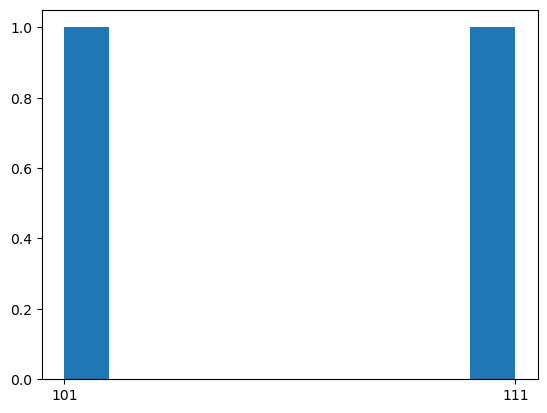

In [32]:
#Run on simulator 
sim = Aer.get_backend("qasm_simulator")

#Transpile circuit for simulator
tqc = transpile(qc, sim)

job = sim.run(tqc, shots=1024)
result = job.result()

#Getting counts
counts = result.get_counts()
print(counts)
plt.hist(counts)
plt.show()


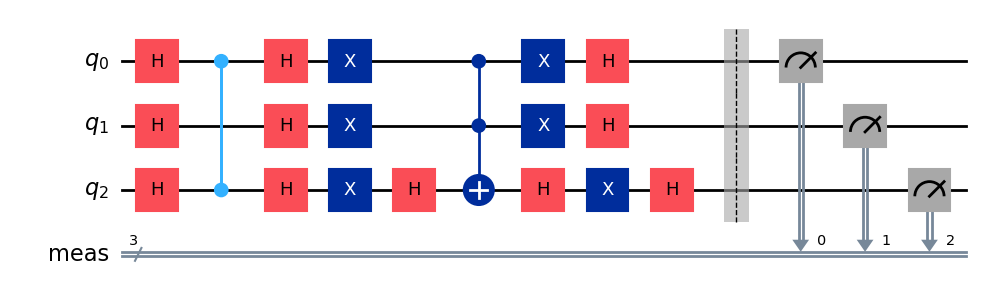

In [33]:
qc.draw("mpl")